# RegimeEnsembleBlender Backtest

Evaluates the `RegimeEnsembleBlender` against historical data, comparing:
- Blended output (regime-weighted) vs equal-weight baseline vs individual models
- Performance across regime groups
- Transition decay impact
- Walk-forward robustness

In [1]:
# Cell 1: Setup & Imports
import sys, types
sys.path.insert(0, '../src')

# Create 'app' namespace alias (regime module uses app.regime.* imports)
import importlib
app = types.ModuleType('app')
app.__path__ = ['../src/libs', '../src/apps']
sys.modules['app'] = app

try:
    import hmmlearn
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hmmlearn', '-q'])

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import yaml
import warnings
from datetime import datetime, timezone
from types import SimpleNamespace
from binance.um_futures import UMFutures

# Project imports
from libs.regime.orchestrator import RegimeOrchestrator
from libs.models.registry import ModelRegistry
from libs.models.blender.ensemble import RegimeEnsembleBlender, REGIME_TO_GROUP
from libs.contracts.signal import ScoringOutput
from libs.optim_utils.scoring_feature_pipeline import build_scoring_feature_df
from libs.optim_utils.scoring import (
    compute_sharpe, compute_max_drawdown, compute_returns, compute_win_rate,
    split_temporal, BARS_PER_YEAR,
)

# Ensure all model subpackages are registered
import libs.models  # noqa: triggers auto_discover

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

client = UMFutures()
print('Setup complete')
print('Registered models:', ModelRegistry.list_all())

Setup complete
Registered models: ['DivergenceEdgeScorer', 'MeanReversion', 'Momentum', 'RegimePullbackScorer', 'RegimeRelativeValueScorer', 'SqueezeBreakout', 'SqueezeBreakoutScorer', 'TrendFollowing']


In [2]:
# Cell 2: Fetch OHLCV Data
_ALL_COLS = [
    'timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time',
    'quote_volume', 'trades', 'taker_buy_base', 'taker_buy_quote', 'ignore'
]

def fetch_ohlcv(symbol: str, interval: str, start_date: str, end_date: str) -> pd.DataFrame:
    """Fetch OHLCV with auto-pagination from Binance Futures."""
    start_ms = int(datetime.strptime(start_date, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    end_ms = int(datetime.strptime(end_date, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    all_rows = []
    cursor = start_ms
    while cursor < end_ms:
        raw = client.klines(symbol, interval, startTime=cursor, endTime=end_ms, limit=1500)
        if not raw:
            break
        all_rows.extend(raw)
        cursor = int(raw[-1][6]) + 1
        if len(raw) < 1500:
            break
        time.sleep(0.15)
    df = pd.DataFrame(all_rows, columns=_ALL_COLS)
    for c in ['open','high','low','close','volume']:
        df[c] = df[c].astype(float)
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True)
    df = df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
    print(f'{symbol} {interval}: {len(df)} bars  [{df.timestamp.iloc[0]} → {df.timestamp.iloc[-1]}]')
    return df

START, END = '2025-12-01', '2026-05-31'

btc_ohlcv = fetch_ohlcv('BTCUSDT', '1h', START, END)
eth_ohlcv = fetch_ohlcv('ETHUSDT', '1h', START, END)

print(f'\nBTC bars: {len(btc_ohlcv)}, ETH bars: {len(eth_ohlcv)}')

BTCUSDT 1h: 4345 bars  [2025-12-01 00:00:00+00:00 → 2026-05-31 00:00:00+00:00]
ETHUSDT 1h: 4345 bars  [2025-12-01 00:00:00+00:00 → 2026-05-31 00:00:00+00:00]

BTC bars: 4345, ETH bars: 4345


In [5]:
# Cell 3: Build Feature DataFrame
import os
os.chdir('../')  # ConfigManager resolves paths from CWD — must be project root
print(f'CWD: {os.getcwd()}')

# Reset ConfigManager singleton so it picks up new CWD
from libs.common.config import ConfigManager
ConfigManager._instance = None

print('Building features for BTCUSDT 1h...')
btc_features = build_scoring_feature_df(btc_ohlcv, 'BTCUSDT', '1h')
print(f'BTC features shape: {btc_features.shape}')
print(f'Feature columns: {sorted(btc_features.columns.tolist())}')
print(f'NaN summary (first 10):\n{btc_features.isna().sum().sort_values(ascending=False).head(10)}')

print('\nBuilding features for ETHUSDT 1h...')
eth_features = build_scoring_feature_df(eth_ohlcv, 'ETHUSDT', '1h')
print(f'ETH features shape: {eth_features.shape}')

CWD: /Users/aloobhujia/flipperAgent
Building features for BTCUSDT 1h...
BTC features shape: (4345, 43)
Feature columns: ['ADLine', 'ADX_adx', 'ADX_minus_di', 'ADX_plus_di', 'ATR', 'BollingerBands_lower', 'BollingerBands_middle', 'BollingerBands_upper', 'CCI', 'EMA_fast', 'EMA_slow', 'KAMA_fast', 'KAMA_slow', 'KeltnerChannel_lower', 'KeltnerChannel_middle', 'KeltnerChannel_upper', 'LinReg', 'MACD_histogram', 'MACD_macd', 'MACD_signal', 'MFI', 'Momentum', 'RSI', 'close', 'eng_altcoin_beta', 'eng_altcoin_market_momentum', 'eng_atr_normalized_return', 'eng_btc_dominance_momentum', 'eng_btc_dominance_regime', 'eng_cross_asset_regime_state', 'eng_market_cap_breadth', 'eng_mean_reversion_z', 'eng_regime_alignment_score', 'eng_regime_score', 'eng_relative_strength_vs_total3', 'eng_residual_momentum', 'eng_squeeze_intensity', 'eng_total3_momentum_z', 'eng_volume_adjusted_momentum', 'high', 'low', 'open', 'volume']
NaN summary (first 10):
eng_residual_momentum           149
eng_volume_adjusted_m

In [6]:
# Cell 4: Run Regime Analysis
print('Running regime analysis on BTC 1h...')
btc_orch = RegimeOrchestrator.create('BTCUSDT', '1h')
btc_regime_df = btc_orch.analyze_series(btc_ohlcv)
print(f'Regime output shape: {btc_regime_df.shape}')
print(f'Regime columns: {btc_regime_df.columns.tolist()}')

# Extract key regime columns into the features df
regime_cols = ['regime', 'p_trending', 'vol_percentile', 'changepoint_prob']
for col in regime_cols:
    if col in btc_regime_df.columns:
        btc_features[col] = btc_regime_df[col].values

# Show regime distribution
print('\n--- Regime Distribution ---')
regime_counts = btc_features['regime'].value_counts()
for regime, count in regime_counts.items():
    group = REGIME_TO_GROUP.get(regime, 'UNKNOWN')
    print(f'  {regime:30s} → {group:16s}  {count:5d} bars ({100*count/len(btc_features):.1f}%)')

# Also run for ETH (cross-validation later)
print('\nRunning regime analysis on ETH 1h...')
eth_orch = RegimeOrchestrator.create('ETHUSDT', '1h')
eth_regime_df = eth_orch.analyze_series(eth_ohlcv)
for col in regime_cols:
    if col in eth_regime_df.columns:
        eth_features[col] = eth_regime_df[col].values
print('ETH regime analysis complete.')

Running regime analysis on BTC 1h...


Regime output shape: (4345, 14)
Regime columns: ['p_trending', 'vol_percentile', 'vol_regime', 'changepoint_prob', 'bcpd_signal', 'bcpd_prob_returns', 'bcpd_prob_volume', 'bcpd_prob_range', 'hilbert_period', 'hilbert_confidence', 'trend_direction', 'regime', 'adaptive_period', 'position_scale']

--- Regime Distribution ---
  QUIET_MR_SQUEEZE               → SQUEEZE            1743 bars (40.1%)
  CHOPPY                         → CHOPPY             1152 bars (26.5%)
  QUIET_MR_RANGE                 → QUIET_RANGE        1090 bars (25.1%)
  CLEAN_TREND_BEAR               → CLEAN_TREND          87 bars (2.0%)
  CLEAN_TREND_FLAT               → CLEAN_TREND          72 bars (1.7%)
  CLEAN_TREND_BULL               → CLEAN_TREND          69 bars (1.6%)
  VOLATILE_TREND_BEAR            → VOLATILE_TREND       57 bars (1.3%)
  VOLATILE_TREND_FLAT            → VOLATILE_TREND       48 bars (1.1%)
  VOLATILE_TREND_BULL            → VOLATILE_TREND       27 bars (0.6%)

Running regime analysis on ETH 1

ETH regime analysis complete.


In [8]:
# Cell 5: Evaluate Individual Scoring Models
# Load the 3 active direction models from the registry
MODEL_NAMES = ['MeanReversion', 'Momentum', 'SqueezeBreakout']

# Read per-model params from configs/models.yaml (CWD is project root now)
with open('configs/models.yaml') as f:
    models_yaml = yaml.safe_load(f)

btc_1h_cfg = models_yaml['models']['assets']['BTCUSDT']['timeframes']['1h']

models = {}
for name in MODEL_NAMES:
    model_cfg = btc_1h_cfg.get(name, {})
    params = model_cfg.get('params', {}) or {}
    cls = ModelRegistry.get(name)
    models[name] = cls(params)
    print(f'Loaded {name} with params: {params}')

# Run batch_evaluate for each model → directions per bar
for name, model in models.items():
    directions = model.batch_evaluate(btc_features)
    btc_features[f'dir_{name}'] = directions
    n_long = (directions == 1).sum()
    n_short = (directions == -1).sum()
    n_flat = (directions == 0).sum()
    print(f'{name}: long={n_long}, short={n_short}, flat={n_flat}')

# Use directions as edge_scores for the blender (direction models emit -1/0/1)
for name in MODEL_NAMES:
    btc_features[f'edge_{name}'] = btc_features[f'dir_{name}'].astype(float)

print('\nModel evaluation complete.')

Loaded MeanReversion with params: {'rsi_oversold': 15, 'rsi_overbought': 76, 'bb_entry_std': 2.6, 'adx_regime_threshold': 26.0, 'holding_period': 3}
Loaded Momentum with params: {'rsi_long_threshold': 70, 'rsi_short_threshold': 34, 'require_macd_positive': True, 'histogram_min_abs': 0.7}
Loaded SqueezeBreakout with params: {'kama_fast_period': 5, 'kama_slow_period': 30, 'mom_period': 20, 'squeeze_lookback': 1, 'ss_threshold': 3, 'cci_period': 5, 'adx_period': 14, 'adx_threshold': 18, 'ad_sma_period': 21, 'mfi_period': 14, 'mfi_sma_period': 9, 'mom_lr_period': 14, 'mom_lr_mom_period': 10}
MeanReversion: long=0, short=3, flat=4342
Momentum: long=181, short=396, flat=3768
SqueezeBreakout: long=48, short=40, flat=4257

Model evaluation complete.


In [9]:
# Cell 6: Run Blender
# Load blender config
blender_cfg = models_yaml['blender']
print('Blender config:')
for k, v in blender_cfg.items():
    if k != 'weights':
        print(f'  {k}: {v}')
print('  weights:')
for group, w in blender_cfg['weights'].items():
    print(f'    {group}: {w}')

# Map model names used in blender config → model names in MODEL_NAMES
# Config uses lowercase: mean_reversion, momentum, squeeze_breakout
CONFIG_TO_MODEL = {
    'mean_reversion': 'MeanReversion',
    'momentum': 'Momentum',
    'squeeze_breakout': 'SqueezeBreakout',
}

# Remap blender weights to use the model registry names
remapped_weights = {}
for group, wdict in blender_cfg['weights'].items():
    remapped_weights[group] = {CONFIG_TO_MODEL[k]: v for k, v in wdict.items()}

blender_config = {
    'transition': blender_cfg.get('transition', {}),
    'mtf': blender_cfg.get('mtf', {}),
    'weights': remapped_weights,
}

blender = RegimeEnsembleBlender(blender_config)

# Iterate chronologically (blender is stateful — hysteresis)
blended_scores = []
equal_scores = []

for idx in range(len(btc_features)):
    row = btc_features.iloc[idx]

    # Skip rows without regime data (warmup)
    if pd.isna(row.get('regime')):
        blended_scores.append(np.nan)
        equal_scores.append(np.nan)
        continue

    # Build per-model ScoringOutput objects
    ts = row.get('timestamp', idx) if 'timestamp' in btc_features.columns else float(idx)
    if hasattr(ts, 'timestamp'):
        ts = ts.timestamp()

    scoring_outputs = []
    edge_vals = []
    for name in MODEL_NAMES:
        edge = row.get(f'edge_{name}', 0.0)
        if pd.isna(edge):
            edge = 0.0
        so = ScoringOutput(
            model_name=name,
            asset='BTCUSDT',
            timeframe='1h',
            timestamp=float(ts),
            edge_score=float(edge),
            conviction=1.0,
        )
        scoring_outputs.append(so)
        edge_vals.append(float(edge))

    # Build regime features as SimpleNamespace
    regime_ns = SimpleNamespace(
        regime=row.get('regime', 'CHOPPY'),
        p_trending=row.get('p_trending', 0.5),
        vol_percentile=row.get('vol_percentile', 50.0),
        changepoint_prob=row.get('changepoint_prob', 0.0),
    )

    # Blend
    result = blender.blend(scoring_outputs, regime_ns)
    blended_scores.append(result.edge_score if result else 0.0)

    # Equal-weight baseline
    equal_scores.append(np.mean(edge_vals))

btc_features['edge_blended'] = blended_scores
btc_features['edge_equal'] = equal_scores

# Quick summary
valid = btc_features.dropna(subset=['edge_blended'])
print(f'\nBlended scores computed: {len(valid)} valid bars')
print(f'Blended mean: {valid["edge_blended"].mean():.4f}, std: {valid["edge_blended"].std():.4f}')
print(f'Equal-wt mean: {valid["edge_equal"].mean():.4f}, std: {valid["edge_equal"].std():.4f}')

Blender config:
  enabled: False
  transition: {'entry_threshold': 0.7, 'exit_threshold': 0.3, 'floor': 0.15}
  mtf: {'confirming_scale': 1.2, 'conflicting_scale': 0.5}
  weights:
    CLEAN_TREND: {'mean_reversion': 0.15, 'momentum': 0.55, 'squeeze_breakout': 0.3}
    VOLATILE_TREND: {'mean_reversion': 0.5, 'momentum': 0.2, 'squeeze_breakout': 0.3}
    QUIET_RANGE: {'mean_reversion': 0.6, 'momentum': 0.1, 'squeeze_breakout': 0.3}
    SQUEEZE: {'mean_reversion': 0.15, 'momentum': 0.25, 'squeeze_breakout': 0.6}
    CHOPPY: {'mean_reversion': 0.3, 'momentum': 0.1, 'squeeze_breakout': 0.6}
    TRANSITION: {'mean_reversion': 0.33, 'momentum': 0.34, 'squeeze_breakout': 0.33}

Blended scores computed: 4345 valid bars
Blended mean: -0.0086, std: 0.1131
Equal-wt mean: -0.0161, std: 0.1336


In [10]:
# Cell 7: Compute Forward Returns
close = btc_features['close'].values
HORIZONS = [1, 4, 12]  # 1h, 4h, 12h

for h in HORIZONS:
    fwd = np.full(len(close), np.nan)
    fwd[:-h] = (close[h:] - close[:-h]) / close[:-h]
    btc_features[f'fwd_ret_{h}'] = fwd

print('Forward returns computed:')
for h in HORIZONS:
    col = f'fwd_ret_{h}'
    vals = btc_features[col].dropna()
    print(f'  h={h:2d}: mean={vals.mean():.6f}, std={vals.std():.4f}, n={len(vals)}')

Forward returns computed:
  h= 1: mean=-0.000026, std=0.0048, n=4344
  h= 4: mean=-0.000101, std=0.0097, n=4341
  h=12: mean=-0.000296, std=0.0166, n=4333


Signal                Horizon   Sharpe  HitRate    MaxDD   CumRet   Trades
------------------------------------------------------------------------
Blended                     1    -0.71    43.6%   -13.6%    -4.2%       72
Blended                     4    -1.98    43.1%   -43.2%   -17.7%       72
Blended                    12    -1.34    46.5%   -59.5%   -22.7%       71
Equal-Weight                1    -0.55    44.0%   -13.4%    -3.5%       68
Equal-Weight                4    -2.04    43.0%   -43.0%   -18.0%       68
Equal-Weight               12    -1.46    46.4%   -59.5%   -23.7%       67
MeanReversion               1   250.71   100.0%     0.0%     0.6%        1
MeanReversion               4  1287.69   100.0%     0.0%     2.9%        1
MeanReversion              12   154.99   100.0%     0.0%     2.7%        1
Momentum                    1     1.22    44.5%   -11.1%     3.6%       39
Momentum                    4     0.21    43.8%   -37.1%    -2.3%       39
Momentum                   

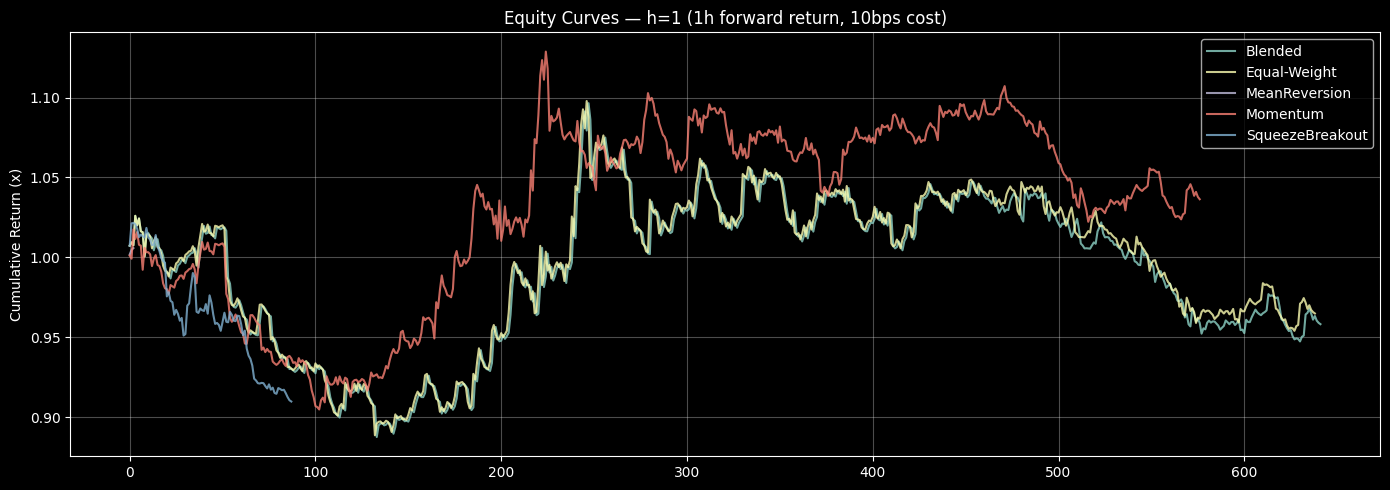

In [11]:
# Cell 8: Signal Performance — Blended vs Equal-Weight vs Individual
COST_BPS = 10.0  # 10 bps round-trip

signal_sources = {
    'Blended': 'edge_blended',
    'Equal-Weight': 'edge_equal',
}
for name in MODEL_NAMES:
    signal_sources[name] = f'edge_{name}'


def evaluate_signal(df, signal_col, horizon=1, cost_bps=10.0):
    """Evaluate a signal column against forward returns."""
    fwd_col = f'fwd_ret_{horizon}'
    mask = df[signal_col].notna() & df[fwd_col].notna() & (df[signal_col] != 0)
    sub = df[mask].copy()
    if len(sub) == 0:
        return {'sharpe': 0.0, 'hit_rate': 0.0, 'max_dd': 0.0, 'cum_ret': 0.0, 'n_trades': 0}

    direction = np.sign(sub[signal_col].values)
    fwd_ret = sub[fwd_col].values
    strat_ret = direction * fwd_ret

    # Transaction costs: apply cost when direction changes
    dir_changes = np.diff(np.concatenate([[0.0], direction]))
    trade_mask = dir_changes != 0
    trade_costs = np.abs(dir_changes) * (cost_bps / 10_000.0)
    strat_ret -= trade_costs[:len(strat_ret)]

    cum = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(cum)
    dd = (cum - running_max) / running_max

    ann_factor = BARS_PER_YEAR.get('1h', 8760)
    sharpe = (np.mean(strat_ret) / np.std(strat_ret) * math.sqrt(ann_factor)) if np.std(strat_ret) > 0 else 0.0
    hit_rate = np.mean(strat_ret > 0)

    return {
        'sharpe': sharpe,
        'hit_rate': hit_rate,
        'max_dd': float(np.min(dd)),
        'cum_ret': float(cum[-1] - 1.0),
        'n_trades': int(trade_mask.sum()),
    }


# Evaluate all signal sources at each horizon
print(f'{"Signal":20s} {"Horizon":>8s} {"Sharpe":>8s} {"HitRate":>8s} {"MaxDD":>8s} {"CumRet":>8s} {"Trades":>8s}')
print('-' * 72)

results_table = []
for label, col in signal_sources.items():
    for h in HORIZONS:
        r = evaluate_signal(btc_features, col, horizon=h, cost_bps=COST_BPS)
        results_table.append({'signal': label, 'horizon': h, **r})
        print(f'{label:20s} {h:8d} {r["sharpe"]:8.2f} {r["hit_rate"]:8.1%} {r["max_dd"]:8.1%} {r["cum_ret"]:8.1%} {r["n_trades"]:8d}')

# Equity curve plot for h=1
fig, ax = plt.subplots(figsize=(14, 5))
for label, col in signal_sources.items():
    mask = btc_features[col].notna() & btc_features['fwd_ret_1'].notna() & (btc_features[col] != 0)
    sub = btc_features[mask]
    if len(sub) == 0:
        continue
    direction = np.sign(sub[col].values)
    fwd = sub['fwd_ret_1'].values
    strat_ret = direction * fwd
    dir_changes = np.diff(np.concatenate([[0.0], direction]))
    trade_costs = np.abs(dir_changes) * (COST_BPS / 10_000.0)
    strat_ret -= trade_costs[:len(strat_ret)]
    cum = np.cumprod(1 + strat_ret)
    ax.plot(cum, label=label, alpha=0.8)

ax.set_title('Equity Curves — h=1 (1h forward return, 10bps cost)')
ax.set_ylabel('Cumulative Return (x)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Group                Bars   Sharpe  HitRate   MeanEdge
-------------------------------------------------------
CLEAN_TREND           228     2.42    39.7%    -0.0737
VOLATILE_TREND        132    22.04    54.2%    -0.0222
QUIET_RANGE          1090    -3.33    43.6%    -0.0054
SQUEEZE              1742     0.47    46.3%    -0.0043
CHOPPY               1152     4.62    48.3%    -0.0039


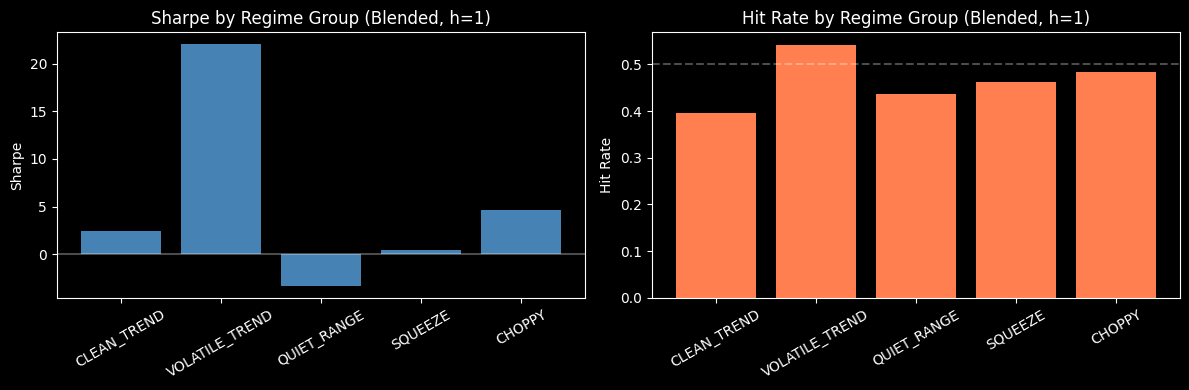

In [12]:
# Cell 9: Performance by Regime Group
GROUPS = ['CLEAN_TREND', 'VOLATILE_TREND', 'QUIET_RANGE', 'SQUEEZE', 'CHOPPY']

btc_features['regime_group'] = btc_features['regime'].map(REGIME_TO_GROUP)

print(f'{"Group":18s} {"Bars":>6s} {"Sharpe":>8s} {"HitRate":>8s} {"MeanEdge":>10s}')
print('-' * 55)

group_stats = []
for grp in GROUPS:
    mask = (btc_features['regime_group'] == grp) & btc_features['edge_blended'].notna() & btc_features['fwd_ret_1'].notna()
    sub = btc_features[mask]
    if len(sub) == 0:
        print(f'{grp:18s} {0:6d} {0:8.2f} {0:8.1%} {0:10.4f}')
        continue

    direction = np.sign(sub['edge_blended'].values)
    fwd = sub['fwd_ret_1'].values
    active = direction != 0
    if active.sum() == 0:
        print(f'{grp:18s} {len(sub):6d} {0:8.2f} {0:8.1%} {sub["edge_blended"].mean():10.4f}')
        continue

    strat_ret = (direction * fwd)[active]
    sharpe = (np.mean(strat_ret) / np.std(strat_ret) * math.sqrt(8760)) if np.std(strat_ret) > 0 else 0.0
    hit_rate = np.mean(strat_ret > 0)
    mean_edge = sub['edge_blended'].mean()

    group_stats.append({'group': grp, 'bars': len(sub), 'sharpe': sharpe, 'hit_rate': hit_rate, 'mean_edge': mean_edge})
    print(f'{grp:18s} {len(sub):6d} {sharpe:8.2f} {hit_rate:8.1%} {mean_edge:10.4f}')

# Bar chart of Sharpe by regime group
if group_stats:
    gdf = pd.DataFrame(group_stats)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(gdf['group'], gdf['sharpe'], color='steelblue')
    axes[0].set_title('Sharpe by Regime Group (Blended, h=1)')
    axes[0].set_ylabel('Sharpe')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].axhline(0, color='white', alpha=0.3)

    axes[1].bar(gdf['group'], gdf['hit_rate'], color='coral')
    axes[1].set_title('Hit Rate by Regime Group (Blended, h=1)')
    axes[1].set_ylabel('Hit Rate')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].axhline(0.5, color='white', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

Variant                Sharpe  HitRate    MaxDD   CumRet
-------------------------------------------------------
With Decay              -0.71    43.6%   -13.6%    -4.2%
No Decay                -0.71    43.6%   -13.6%    -4.2%


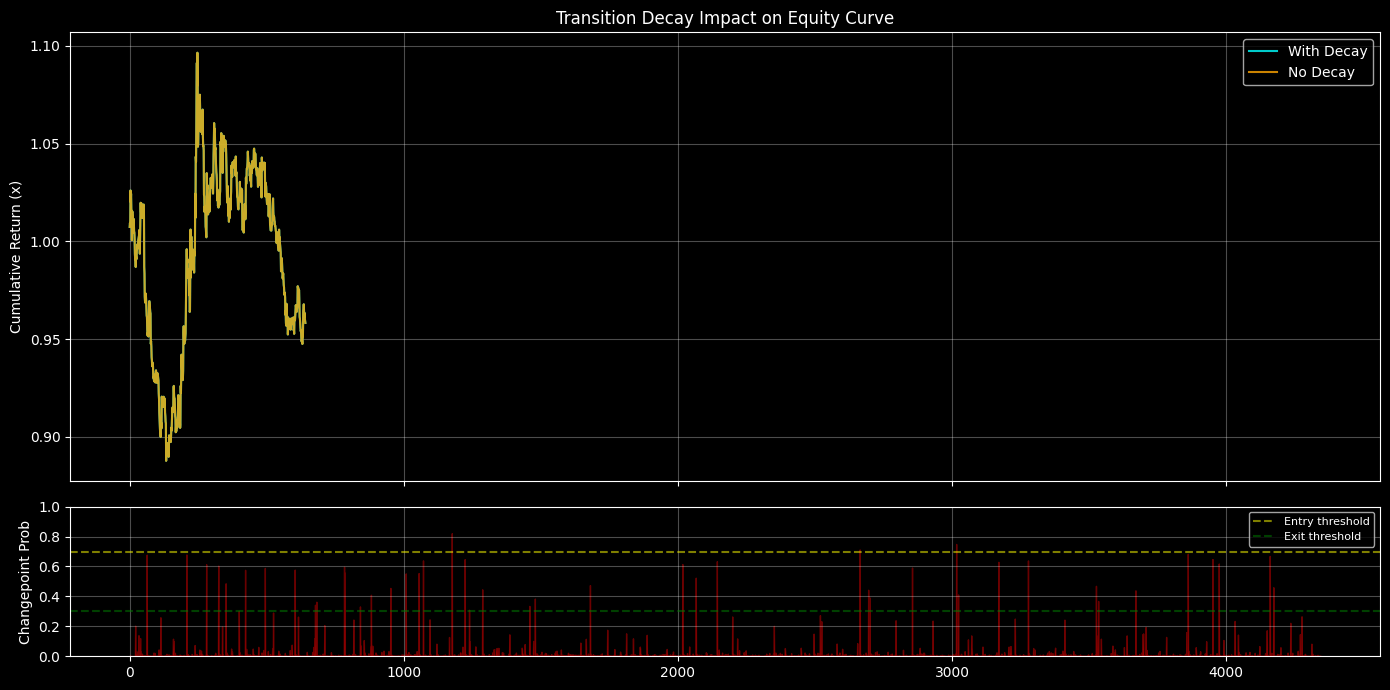

In [13]:
# Cell 10: Transition Decay Analysis
# Compare blender WITH decay vs WITHOUT decay (decay=1.0 always)

# Re-run blender with floor=1.0 (no decay effect)
no_decay_cfg = {
    'transition': {'entry_threshold': 999.0, 'exit_threshold': 0.0, 'floor': 1.0},
    'mtf': blender_cfg.get('mtf', {}),
    'weights': remapped_weights,
}
blender_no_decay = RegimeEnsembleBlender(no_decay_cfg)

no_decay_scores = []
for idx in range(len(btc_features)):
    row = btc_features.iloc[idx]
    if pd.isna(row.get('regime')):
        no_decay_scores.append(np.nan)
        continue

    ts = row.get('timestamp', idx) if 'timestamp' in btc_features.columns else float(idx)
    if hasattr(ts, 'timestamp'):
        ts = ts.timestamp()

    scoring_outputs = []
    for name in MODEL_NAMES:
        edge = row.get(f'edge_{name}', 0.0)
        if pd.isna(edge):
            edge = 0.0
        so = ScoringOutput(
            model_name=name, asset='BTCUSDT', timeframe='1h',
            timestamp=float(ts), edge_score=float(edge), conviction=1.0,
        )
        scoring_outputs.append(so)

    regime_ns = SimpleNamespace(
        regime=row.get('regime', 'CHOPPY'),
        p_trending=row.get('p_trending', 0.5),
        vol_percentile=row.get('vol_percentile', 50.0),
        changepoint_prob=row.get('changepoint_prob', 0.0),
    )

    result = blender_no_decay.blend(scoring_outputs, regime_ns)
    no_decay_scores.append(result.edge_score if result else 0.0)

btc_features['edge_no_decay'] = no_decay_scores

# Compare performance
print(f'{"Variant":20s} {"Sharpe":>8s} {"HitRate":>8s} {"MaxDD":>8s} {"CumRet":>8s}')
print('-' * 55)
for label, col in [('With Decay', 'edge_blended'), ('No Decay', 'edge_no_decay')]:
    r = evaluate_signal(btc_features, col, horizon=1, cost_bps=COST_BPS)
    print(f'{label:20s} {r["sharpe"]:8.2f} {r["hit_rate"]:8.1%} {r["max_dd"]:8.1%} {r["cum_ret"]:8.1%}')

# Plot changepoint_prob alongside equity curves
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

for label, col, color in [('With Decay', 'edge_blended', 'cyan'), ('No Decay', 'edge_no_decay', 'orange')]:
    mask = btc_features[col].notna() & btc_features['fwd_ret_1'].notna() & (btc_features[col] != 0)
    sub = btc_features[mask]
    if len(sub) == 0:
        continue
    direction = np.sign(sub[col].values)
    fwd = sub['fwd_ret_1'].values
    strat_ret = direction * fwd
    dir_changes = np.diff(np.concatenate([[0.0], direction]))
    trade_costs = np.abs(dir_changes) * (COST_BPS / 10_000.0)
    strat_ret -= trade_costs[:len(strat_ret)]
    cum = np.cumprod(1 + strat_ret)
    ax1.plot(cum, label=label, color=color, alpha=0.8)

ax1.set_title('Transition Decay Impact on Equity Curve')
ax1.set_ylabel('Cumulative Return (x)')
ax1.legend()
ax1.grid(alpha=0.3)

cp = btc_features['changepoint_prob'].dropna()
ax2.fill_between(cp.index, cp.values, alpha=0.4, color='red')
ax2.set_ylabel('Changepoint Prob')
ax2.set_ylim(0, 1)
ax2.axhline(0.70, color='yellow', linestyle='--', alpha=0.5, label='Entry threshold')
ax2.axhline(0.30, color='green', linestyle='--', alpha=0.5, label='Exit threshold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Cell 11: Walk-Forward Robustness (Simple)
# Split 60/20/20 using split_temporal

# Drop NaN rows for clean evaluation
eval_df = btc_features.dropna(subset=['edge_blended', 'fwd_ret_1', 'regime']).copy()
print(f'Evaluation rows after dropping NaN: {len(eval_df)}')

train_df, test_df, val_df = split_temporal(eval_df, train=0.6, test=0.2, val=0.2)
print(f'Train: {len(train_df)}, Test: {len(test_df)}, Val: {len(val_df)}')

print(f'\n{"Split":8s} {"Sharpe":>8s} {"HitRate":>8s} {"MaxDD":>8s} {"CumRet":>8s} {"Trades":>8s}')
print('-' * 50)

split_results = {}
for split_name, split_df in [('Train', train_df), ('Test', test_df), ('Val', val_df)]:
    r = evaluate_signal(split_df, 'edge_blended', horizon=1, cost_bps=COST_BPS)
    split_results[split_name] = r
    print(f'{split_name:8s} {r["sharpe"]:8.2f} {r["hit_rate"]:8.1%} {r["max_dd"]:8.1%} {r["cum_ret"]:8.1%} {r["n_trades"]:8d}')

# Also run equal-weight for comparison
print(f'\n--- Equal-Weight Baseline ---')
print(f'{"Split":8s} {"Sharpe":>8s} {"HitRate":>8s} {"CumRet":>8s}')
print('-' * 35)
for split_name, split_df in [('Train', train_df), ('Test', test_df), ('Val', val_df)]:
    r = evaluate_signal(split_df, 'edge_equal', horizon=1, cost_bps=COST_BPS)
    print(f'{split_name:8s} {r["sharpe"]:8.2f} {r["hit_rate"]:8.1%} {r["cum_ret"]:8.1%}')

# Overfitting check
train_sharpe = split_results['Train']['sharpe']
val_sharpe = split_results['Val']['sharpe']
if train_sharpe > 0 and val_sharpe < 0.5 * train_sharpe:
    print(f'\n⚠️  OVERFITTING WARNING: Val Sharpe ({val_sharpe:.2f}) < 50% of Train Sharpe ({train_sharpe:.2f})')
else:
    print(f'\n✓ Robustness check passed: Val Sharpe ({val_sharpe:.2f}) vs Train Sharpe ({train_sharpe:.2f})')

# Cross-validate on ETH
print('\n--- ETH Cross-Validation ---')
# Run models on ETH features
for name, model in models.items():
    try:
        directions = model.batch_evaluate(eth_features)
        eth_features[f'edge_{name}'] = directions.astype(float)
    except Exception as e:
        print(f'  {name} failed on ETH: {e}')
        eth_features[f'edge_{name}'] = 0.0

# Run blender on ETH
eth_blender = RegimeEnsembleBlender(blender_config)
eth_blended = []
for idx in range(len(eth_features)):
    row = eth_features.iloc[idx]
    if pd.isna(row.get('regime')):
        eth_blended.append(np.nan)
        continue
    ts = row.get('timestamp', idx) if 'timestamp' in eth_features.columns else float(idx)
    if hasattr(ts, 'timestamp'):
        ts = ts.timestamp()
    scoring_outputs = []
    for name in MODEL_NAMES:
        edge = row.get(f'edge_{name}', 0.0)
        if pd.isna(edge):
            edge = 0.0
        scoring_outputs.append(ScoringOutput(
            model_name=name, asset='ETHUSDT', timeframe='1h',
            timestamp=float(ts), edge_score=float(edge), conviction=1.0,
        ))
    regime_ns = SimpleNamespace(
        regime=row.get('regime', 'CHOPPY'),
        p_trending=row.get('p_trending', 0.5),
        vol_percentile=row.get('vol_percentile', 50.0),
        changepoint_prob=row.get('changepoint_prob', 0.0),
    )
    result = eth_blender.blend(scoring_outputs, regime_ns)
    eth_blended.append(result.edge_score if result else 0.0)

eth_features['edge_blended'] = eth_blended

# Forward returns for ETH
eth_close = eth_features['close'].values
fwd = np.full(len(eth_close), np.nan)
fwd[:-1] = (eth_close[1:] - eth_close[:-1]) / eth_close[:-1]
eth_features['fwd_ret_1'] = fwd

eth_r = evaluate_signal(eth_features, 'edge_blended', horizon=1, cost_bps=COST_BPS)
print(f'ETH Blended: Sharpe={eth_r["sharpe"]:.2f}, HitRate={eth_r["hit_rate"]:.1%}, CumRet={eth_r["cum_ret"]:.1%}')

Evaluation rows after dropping NaN: 4344
Train: 2606, Test: 869, Val: 869

Split      Sharpe  HitRate    MaxDD   CumRet   Trades
--------------------------------------------------
Train        1.46    45.5%   -13.5%     3.4%       41
Test        -3.11    42.3%    -4.0%    -2.2%       16
Val        -12.31    37.9%    -6.4%    -5.5%       17

--- Equal-Weight Baseline ---
Split      Sharpe  HitRate   CumRet
-----------------------------------
Train        1.50    45.6%     3.6%
Test        -2.27    43.7%    -1.6%
Val        -12.31    37.9%    -5.5%

⚠️  OVERFITTING WARNING: Val Sharpe (-12.31) < 50% of Train Sharpe (1.46)

--- ETH Cross-Validation ---
ETH Blended: Sharpe=0.00, HitRate=0.0%, CumRet=0.0%


In [15]:
## === SQUEEZE BREAKOUT DIAGNOSIS ===
import numpy as np
import pandas as pd

sb_dir = btc_features['dir_SqueezeBreakout']
sb_edge = btc_features['edge_SqueezeBreakout']

# Basic signal stats
n_long = (sb_dir == 1).sum()
n_short = (sb_dir == -1).sum()
n_flat = (sb_dir == 0).sum()
print(f"SqueezeBreakout signals: long={n_long}, short={n_short}, flat={n_flat}")
print(f"Total signals: {n_long + n_short} / {len(sb_dir)} bars")
print()

# 1. Forward returns for SB signals at h=1, h=4, h=12
for h in [1, 4, 12]:
    col = f'fwd_ret_{h}'
    if col in btc_features.columns:
        long_ret = btc_features.loc[sb_dir == 1, col]
        short_ret = btc_features.loc[sb_dir == -1, col]
        # For shorts, actual PnL = -1 * fwd_ret (we shorted)
        all_pnl = pd.concat([long_ret, -short_ret])
        
        print(f"--- h={h} ---")
        print(f"  Long signals ({len(long_ret)}): mean fwd_ret = {long_ret.mean()*100:.3f}%  median = {long_ret.median()*100:.3f}%")
        print(f"  Short signals ({len(short_ret)}): mean fwd_ret = {short_ret.mean()*100:.3f}%  median = {short_ret.median()*100:.3f}%")
        print(f"  Combined PnL: mean = {all_pnl.mean()*100:.3f}%  hit_rate = {(all_pnl > 0).mean()*100:.1f}%")
        print(f"  FLIPPED PnL: mean = {(-all_pnl).mean()*100:.3f}%  hit_rate = {(all_pnl < 0).mean()*100:.1f}%")
        
        if len(all_pnl) > 1:
            sharpe = all_pnl.mean() / all_pnl.std() * np.sqrt(8760) if all_pnl.std() > 0 else 0
            flip_sharpe = (-all_pnl).mean() / all_pnl.std() * np.sqrt(8760) if all_pnl.std() > 0 else 0
            print(f"  Sharpe (h={h}): {sharpe:.2f}  |  FLIPPED Sharpe: {flip_sharpe:.2f}")
        print()

# 2. Regime distribution of SB signals
print("\n=== SB Signal Regime Distribution ===")
regime_col = 'regime_group' if 'regime_group' in btc_features.columns else 'regime'
if regime_col in btc_features.columns:
    sb_signals = btc_features[sb_dir != 0]
    regime_dist = sb_signals[regime_col].value_counts()
    overall_dist = btc_features[regime_col].value_counts(normalize=True)
    print(f"\nSB signals by {regime_col}:")
    for regime in regime_dist.index:
        n = regime_dist[regime]
        pct = n / len(sb_signals) * 100
        expected_pct = overall_dist.get(regime, 0) * 100
        print(f"  {regime}: {n} signals ({pct:.1f}%) [regime is {expected_pct:.1f}% of data]")

# 3. Long vs Short by regime  
print("\n=== Long vs Short by Regime ===")
if regime_col in btc_features.columns:
    for regime in sorted(btc_features[regime_col].unique()):
        rmask = btc_features[regime_col] == regime
        nl = ((sb_dir == 1) & rmask).sum()
        ns = ((sb_dir == -1) & rmask).sum()
        if nl + ns > 0:
            fwd = btc_features.loc[(sb_dir != 0) & rmask, 'fwd_ret_1']
            pnl_series = btc_features.loc[(sb_dir == 1) & rmask, 'fwd_ret_1'].tolist() + \
                         (-btc_features.loc[(sb_dir == -1) & rmask, 'fwd_ret_1']).tolist()
            mean_pnl = np.mean(pnl_series) if pnl_series else 0
            print(f"  {regime}: long={nl}, short={ns}, mean_pnl={mean_pnl*100:.3f}%")

SqueezeBreakout signals: long=48, short=40, flat=4257
Total signals: 88 / 4345 bars

--- h=1 ---
  Long signals (48): mean fwd_ret = -0.014%  median = -0.032%
  Short signals (40): mean fwd_ret = -0.013%  median = 0.049%
  Combined PnL: mean = -0.002%  hit_rate = 45.5%
  FLIPPED PnL: mean = 0.002%  hit_rate = 54.5%
  Sharpe (h=1): -0.33  |  FLIPPED Sharpe: 0.33

--- h=4 ---
  Long signals (48): mean fwd_ret = -0.186%  median = 0.018%
  Short signals (40): mean fwd_ret = 0.090%  median = 0.080%
  Combined PnL: mean = -0.143%  hit_rate = 48.9%
  FLIPPED PnL: mean = 0.143%  hit_rate = 51.1%
  Sharpe (h=4): -13.75  |  FLIPPED Sharpe: 13.75

--- h=12 ---
  Long signals (48): mean fwd_ret = -0.231%  median = -0.218%
  Short signals (40): mean fwd_ret = 0.194%  median = 0.117%
  Combined PnL: mean = -0.214%  hit_rate = 42.0%
  FLIPPED PnL: mean = 0.214%  hit_rate = 56.8%
  Sharpe (h=12): -15.85  |  FLIPPED Sharpe: 15.85


=== SB Signal Regime Distribution ===

SB signals by regime_group:
  SQ

In [16]:
## === SQUEEZE MECHANICS DEEP DIVE ===
import numpy as np, pandas as pd

# Reconstruct squeeze state from raw bands
bb_up = btc_features['BollingerBands_upper']
bb_lo = btc_features['BollingerBands_lower']
kc_up = btc_features['KeltnerChannel_upper']
kc_lo = btc_features['KeltnerChannel_lower']

squeeze_on = (bb_up < kc_up) & (bb_lo > kc_lo)
print(f"Squeeze ON bars: {squeeze_on.sum()} / {len(squeeze_on)} ({squeeze_on.mean()*100:.1f}%)")

# Squeeze release detection (matching model logic with lookback=1)
lookback = 1
was_squeezed = squeeze_on.rolling(window=lookback, min_periods=1).max().astype(bool)
squeeze_release = (~squeeze_on) & was_squeezed.shift(1, fill_value=False)
print(f"Squeeze release bars: {squeeze_release.sum()}")

# How many squeeze releases pass the KAMA + lr_mom filters?
sb_dir = btc_features['dir_SqueezeBreakout']
sb_active = sb_dir != 0
print(f"Squeeze releases that become SB signals: {sb_active.sum()} / {squeeze_release.sum()} ({sb_active.sum()/max(1,squeeze_release.sum())*100:.1f}%)")

# Check: are there squeeze release bars that are NOT SB signals? Why?
release_no_signal = squeeze_release & ~sb_active
release_with_signal = squeeze_release & sb_active
print(f"Squeeze releases filtered out: {release_no_signal.sum()}")

# Analyze the TIMING - what happens to price BEFORE the squeeze release?
# This tells us if SB is chasing or anticipating
print("\n=== Price action around SB signals ===")
sb_indices = btc_features.index[sb_active]
close = btc_features['close']

for h_label, h_back in [('pre-5 bars', 5), ('pre-10 bars', 10), ('pre-20 bars', 20)]:
    pre_ret = []
    for idx_pos in range(len(btc_features)):
        if sb_active.iloc[idx_pos] and idx_pos >= h_back:
            r = (close.iloc[idx_pos] / close.iloc[idx_pos - h_back]) - 1
            pre_ret.append(r * sb_dir.iloc[idx_pos])  # Align with direction
    if pre_ret:
        print(f"  {h_label} price move (aligned w/ signal dir): mean={np.mean(pre_ret)*100:.3f}%, median={np.median(pre_ret)*100:.3f}%")

# Check if SB is buying tops and selling bottoms
print("\n=== Is SB chasing momentum that reverses? ===")
for h in [1, 4, 12]:
    col = f'fwd_ret_{h}'
    if col in btc_features.columns:
        # For each signal, compare pre-return direction with forward return
        longs = btc_features.loc[sb_dir == 1].copy()
        shorts = btc_features.loc[sb_dir == -1].copy()
        
        long_pre5 = []
        for idx_pos in range(len(btc_features)):
            if sb_dir.iloc[idx_pos] == 1 and idx_pos >= 5:
                long_pre5.append((close.iloc[idx_pos] / close.iloc[idx_pos - 5]) - 1)
        
        if long_pre5:
            pre_up = sum(1 for x in long_pre5 if x > 0)
            print(f"  h={h}: {pre_up}/{len(long_pre5)} longs came after 5-bar UP move ({pre_up/len(long_pre5)*100:.0f}%)")
            print(f"       Long mean fwd_ret_{h}: {longs[col].mean()*100:.3f}% → CHASING = {pre_up/len(long_pre5) > 0.6}")

# Consecutive signals analysis
print("\n=== Signal clustering ===")
signal_positions = btc_features.index[sb_active].tolist()
gaps = [signal_positions[i+1] - signal_positions[i] for i in range(len(signal_positions)-1)]
if gaps:
    # Convert to integer gaps
    int_positions = [btc_features.index.get_loc(p) for p in signal_positions]
    int_gaps = [int_positions[i+1] - int_positions[i] for i in range(len(int_positions)-1)]
    print(f"  Gap between signals: min={min(int_gaps)}, median={np.median(int_gaps):.0f}, max={max(int_gaps)} bars")
    print(f"  Signals within 3 bars of each other: {sum(1 for g in int_gaps if g <= 3)}")
    print(f"  Signals within 1 bar of each other: {sum(1 for g in int_gaps if g <= 1)}")

Squeeze ON bars: 959 / 4345 (22.1%)
Squeeze release bars: 129
Squeeze releases that become SB signals: 88 / 129 (68.2%)
Squeeze releases filtered out: 41

=== Price action around SB signals ===
  pre-5 bars price move (aligned w/ signal dir): mean=1.217%, median=1.109%
  pre-10 bars price move (aligned w/ signal dir): mean=1.305%, median=1.108%
  pre-20 bars price move (aligned w/ signal dir): mean=1.233%, median=1.081%

=== Is SB chasing momentum that reverses? ===
  h=1: 47/48 longs came after 5-bar UP move (98%)
       Long mean fwd_ret_1: -0.014% → CHASING = True
  h=4: 47/48 longs came after 5-bar UP move (98%)
       Long mean fwd_ret_4: -0.186% → CHASING = True
  h=12: 47/48 longs came after 5-bar UP move (98%)
       Long mean fwd_ret_12: -0.231% → CHASING = True

=== Signal clustering ===
  Gap between signals: min=2, median=36, max=213 bars
  Signals within 3 bars of each other: 3
  Signals within 1 bar of each other: 0


In [17]:
## === SS FILTER ANALYSIS + SQUEEZE LOOKBACK SENSITIVITY ===
import numpy as np, pandas as pd

close = btc_features['close']
high = btc_features['high'] if 'high' in btc_features.columns else close
low = btc_features['low'] if 'low' in btc_features.columns else close
bb_up = btc_features['BollingerBands_upper']
bb_lo = btc_features['BollingerBands_lower']
kc_up = btc_features['KeltnerChannel_upper']
kc_lo = btc_features['KeltnerChannel_lower']
kama_fast = btc_features['KAMA_fast']
kama_slow = btc_features['KAMA_slow']

squeeze_on = (bb_up < kc_up) & (bb_lo > kc_lo)

# 1. What if we change squeeze_lookback?
print("=== Lookback Sensitivity (no SS filter) ===")
from libs.models.squeeze_breakout.math_utils import rolling_linreg
mom_period = 20
hh = high.rolling(window=mom_period, min_periods=mom_period).max()
ll = low.rolling(window=mom_period, min_periods=mom_period).min()
sma_c = close.rolling(window=mom_period, min_periods=mom_period).mean()
midline = (hh + ll) / 2.0
delta = close - (midline + sma_c) / 2.0
lr_arr = rolling_linreg(delta.values.astype(np.float64), mom_period)
lr_mom = pd.Series(lr_arr, index=btc_features.index)

for lb in [1, 2, 3, 5]:
    was_sq = squeeze_on.rolling(window=lb, min_periods=1).max().astype(bool)
    sq_release = (~squeeze_on) & was_sq.shift(1, fill_value=False)
    
    longs = sq_release & (kama_fast > kama_slow) & (lr_mom > 0)
    shorts = sq_release & (kama_fast < kama_slow) & (lr_mom < 0)
    
    n_sig = longs.sum() + shorts.sum()
    
    if n_sig > 0 and 'fwd_ret_1' in btc_features.columns:
        pnl_1 = pd.concat([
            btc_features.loc[longs, 'fwd_ret_1'],
            -btc_features.loc[shorts, 'fwd_ret_1']
        ])
        pnl_4 = pd.concat([
            btc_features.loc[longs, 'fwd_ret_4'],
            -btc_features.loc[shorts, 'fwd_ret_4']
        ])
        hr1 = (pnl_1 > 0).mean() * 100
        hr4 = (pnl_4 > 0).mean() * 100
        s1 = pnl_1.mean() / pnl_1.std() * np.sqrt(8760) if pnl_1.std() > 0 else 0
        s4 = pnl_4.mean() / pnl_4.std() * np.sqrt(8760) if pnl_4.std() > 0 else 0
        print(f"  lookback={lb}: {n_sig} signals, h1_HR={hr1:.1f}%, h1_Sharpe={s1:.2f}, h4_Sharpe={s4:.2f}")

# 2. What does SS=3 filter actually do? Compare with SS=0 (no filter)
print("\n=== SS Filter Impact ===")
# Re-run the model with ss_threshold=0 to get unfiltered signals
from libs.models.registry import ModelRegistry
sb_no_filter = ModelRegistry.get("SqueezeBreakout")({'ss_threshold': 0,
    'kama_fast_period': 5, 'kama_slow_period': 30, 'mom_period': 20,
    'squeeze_lookback': 1, 'cci_period': 5, 'adx_period': 14,
    'adx_threshold': 18, 'ad_sma_period': 21, 'mfi_period': 14,
    'mfi_sma_period': 9, 'mom_lr_period': 14, 'mom_lr_mom_period': 10})
dir_nofilt = sb_no_filter.batch_evaluate(btc_features)
n_nf = (dir_nofilt != 0).sum()
print(f"  SS=0 (no filter): {n_nf} signals")
print(f"  SS=3 (current):   {(btc_features['dir_SqueezeBreakout'] != 0).sum()} signals")
print(f"  SS filter removed {n_nf - (btc_features['dir_SqueezeBreakout'] != 0).sum()} signals")

if n_nf > 0 and 'fwd_ret_1' in btc_features.columns:
    pnl_nf = pd.concat([
        btc_features.loc[dir_nofilt == 1, 'fwd_ret_1'],
        -btc_features.loc[dir_nofilt == -1, 'fwd_ret_1']
    ])
    s_nf = pnl_nf.mean() / pnl_nf.std() * np.sqrt(8760) if pnl_nf.std() > 0 else 0
    print(f"  SS=0 Sharpe(h=1): {s_nf:.2f}, hit_rate: {(pnl_nf > 0).mean()*100:.1f}%")

# 3. What if we just trade the OPPOSITE of SB?
print("\n=== What if we simply FLIP SB directions? ===")
sb_dir = btc_features['dir_SqueezeBreakout']
for h in [1, 4, 12]:
    col = f'fwd_ret_{h}'
    if col in btc_features.columns:
        # Flip: long→short, short→long
        flipped_pnl = pd.concat([
            -btc_features.loc[sb_dir == 1, col],   # was long, now short
            btc_features.loc[sb_dir == -1, col]    # was short, now long
        ])
        s = flipped_pnl.mean() / flipped_pnl.std() * np.sqrt(8760) if flipped_pnl.std() > 0 else 0
        hr = (flipped_pnl > 0).mean() * 100
        cum = flipped_pnl.sum() * 100
        print(f"  h={h}: Flipped Sharpe={s:.2f}, HR={hr:.1f}%, cumPnL={cum:.2f}%")

# 4. HOW LATE is SB to the move? Check bars since squeeze started
print("\n=== Squeeze Duration Before Release ===")
# Count how many consecutive squeeze bars preceded each release
sq_arr = squeeze_on.values
squeeze_durations = []
current_run = 0
for i in range(len(sq_arr)):
    if sq_arr[i]:
        current_run += 1
    else:
        if current_run > 0 and sb_dir.iloc[i] != 0:
            squeeze_durations.append(current_run)
        current_run = 0
        
if squeeze_durations:
    print(f"  Bars in squeeze before SB signal: min={min(squeeze_durations)}, median={np.median(squeeze_durations):.0f}, max={max(squeeze_durations)}")
    print(f"  Mean squeeze duration: {np.mean(squeeze_durations):.1f} bars")
    print(f"  Single-bar squeezes: {sum(1 for d in squeeze_durations if d == 1)} ({sum(1 for d in squeeze_durations if d == 1)/len(squeeze_durations)*100:.0f}%)")

=== Lookback Sensitivity (no SS filter) ===
  lookback=1: 105 signals, h1_HR=43.8%, h1_Sharpe=1.93, h4_Sharpe=-8.39
  lookback=2: 211 signals, h1_HR=46.4%, h1_Sharpe=4.25, h4_Sharpe=-9.32
  lookback=3: 315 signals, h1_HR=46.3%, h1_Sharpe=-0.81, h4_Sharpe=-12.94
  lookback=5: 510 signals, h1_HR=45.7%, h1_Sharpe=-2.75, h4_Sharpe=-10.40

=== SS Filter Impact ===
  SS=0 (no filter): 105 signals
  SS=3 (current):   88 signals
  SS filter removed 17 signals
  SS=0 Sharpe(h=1): 1.93, hit_rate: 43.8%

=== What if we simply FLIP SB directions? ===
  h=1: Flipped Sharpe=0.33, HR=54.5%, cumPnL=0.19%
  h=4: Flipped Sharpe=13.75, HR=51.1%, cumPnL=12.55%
  h=12: Flipped Sharpe=15.85, HR=56.8%, cumPnL=18.65%

=== Squeeze Duration Before Release ===
  Bars in squeeze before SB signal: min=1, median=6, max=32
  Mean squeeze duration: 7.8 bars
  Single-bar squeezes: 6 (7%)


In [18]:
## === SS FILTER QUALITY: filtered-out vs kept signals ===
import numpy as np, pandas as pd

# Signals with no SS filter
dir_nofilt = sb_no_filter.batch_evaluate(btc_features)

# Which signals were REMOVED by SS filter?
sb_dir = btc_features['dir_SqueezeBreakout']
kept = (sb_dir != 0)
all_sig = (dir_nofilt != 0)
removed = all_sig & ~kept

print(f"Kept by SS≥3: {kept.sum()} signals")
print(f"Removed by SS<3: {removed.sum()} signals")

for h in [1, 4]:
    col = f'fwd_ret_{h}'
    # PnL of KEPT signals
    kept_pnl = pd.concat([
        btc_features.loc[kept & (sb_dir == 1), col],
        -btc_features.loc[kept & (sb_dir == -1), col]
    ])
    # PnL of REMOVED signals  
    rem_pnl = pd.concat([
        btc_features.loc[removed & (dir_nofilt == 1), col],
        -btc_features.loc[removed & (dir_nofilt == -1), col]
    ])
    
    if len(kept_pnl) > 0 and len(rem_pnl) > 0:
        print(f"\n  h={h}:")
        print(f"    KEPT (SS≥3): mean PnL = {kept_pnl.mean()*100:.3f}%, HR = {(kept_pnl>0).mean()*100:.1f}%")
        print(f"    REMOVED (SS<3): mean PnL = {rem_pnl.mean()*100:.3f}%, HR = {(rem_pnl>0).mean()*100:.1f}%")
        print(f"    → SS filter keeping {'WORSE' if kept_pnl.mean() < rem_pnl.mean() else 'BETTER'} signals")

# What's the actual forward return CONDITIONAL on how far price already moved?
print("\n=== ENTRY LATENESS: pre-signal return vs forward return ===")
sb_mask = sb_dir != 0
results = []
for i in range(len(btc_features)):
    if sb_mask.iloc[i] and i >= 10:
        pre_ret = (close.iloc[i] / close.iloc[i-10] - 1) * sb_dir.iloc[i]
        fwd_ret = btc_features['fwd_ret_4'].iloc[i] * sb_dir.iloc[i]
        results.append({'pre_ret': pre_ret, 'fwd_ret': fwd_ret, 'dir': sb_dir.iloc[i]})

df_timing = pd.DataFrame(results)
if len(df_timing) > 0:
    # Split by how much price already moved
    median_pre = df_timing['pre_ret'].median()
    early = df_timing[df_timing['pre_ret'] < median_pre]
    late = df_timing[df_timing['pre_ret'] >= median_pre]
    print(f"  'Early' entries (pre_ret < median {median_pre*100:.2f}%):")
    print(f"    mean fwd_ret(4): {early['fwd_ret'].mean()*100:.3f}%, n={len(early)}")
    print(f"  'Late' entries (pre_ret ≥ median):")
    print(f"    mean fwd_ret(4): {late['fwd_ret'].mean()*100:.3f}%, n={len(late)}")
    print(f"  Correlation(pre_10bar_ret, fwd_4_ret): {df_timing['pre_ret'].corr(df_timing['fwd_ret']):.3f}")

Kept by SS≥3: 88 signals
Removed by SS<3: 17 signals

  h=1:
    KEPT (SS≥3): mean PnL = -0.002%, HR = 45.5%
    REMOVED (SS<3): mean PnL = 0.083%, HR = 35.3%
    → SS filter keeping WORSE signals

  h=4:
    KEPT (SS≥3): mean PnL = -0.143%, HR = 48.9%
    REMOVED (SS<3): mean PnL = 0.216%, HR = 70.6%
    → SS filter keeping WORSE signals

=== ENTRY LATENESS: pre-signal return vs forward return ===
  'Early' entries (pre_ret < median 1.11%):
    mean fwd_ret(4): -0.114%, n=44
  'Late' entries (pre_ret ≥ median):
    mean fwd_ret(4): -0.172%, n=44
  Correlation(pre_10bar_ret, fwd_4_ret): 0.023


In [19]:
# Cell: Re-run blender with SB disabled (weights=0) + Momentum-only comparison
# ============================================================================

# --- Config A: SB zeroed, renormalize MR + Mom weights ---
no_sb_weights = {}
for group, wdict in remapped_weights.items():
    sb_w = wdict.get('SqueezeBreakout', 0.0)
    remaining = {k: v for k, v in wdict.items() if k != 'SqueezeBreakout'}
    total = sum(remaining.values())
    if total > 0:
        no_sb_weights[group] = {k: v / total for k, v in remaining.items()}
    else:
        no_sb_weights[group] = remaining

print('--- Renormalized weights (no SB) ---')
for g, w in no_sb_weights.items():
    print(f'  {g}: {w}')

no_sb_config = {
    'transition': blender_cfg.get('transition', {}),
    'mtf': blender_cfg.get('mtf', {}),
    'weights': no_sb_weights,
}
blender_no_sb = RegimeEnsembleBlender(no_sb_config)

# Run blender without SB
no_sb_scores = []
for idx in range(len(btc_features)):
    row = btc_features.iloc[idx]
    if pd.isna(row.get('regime')):
        no_sb_scores.append(np.nan)
        continue
    ts = row.get('timestamp', idx) if 'timestamp' in btc_features.columns else float(idx)
    if hasattr(ts, 'timestamp'):
        ts = ts.timestamp()
    # Only MR + Momentum outputs
    scoring_outputs = []
    for name in ['MeanReversion', 'Momentum']:
        edge = row.get(f'edge_{name}', 0.0)
        if pd.isna(edge):
            edge = 0.0
        scoring_outputs.append(ScoringOutput(
            model_name=name, asset='BTCUSDT', timeframe='1h',
            timestamp=float(ts), edge_score=float(edge), conviction=1.0,
        ))
    regime_ns = SimpleNamespace(
        regime=row.get('regime', 'CHOPPY'),
        p_trending=row.get('p_trending', 0.5),
        vol_percentile=row.get('vol_percentile', 50.0),
        changepoint_prob=row.get('changepoint_prob', 0.0),
    )
    result = blender_no_sb.blend(scoring_outputs, regime_ns)
    no_sb_scores.append(result.edge_score if result else 0.0)

btc_features['edge_no_sb'] = no_sb_scores

# --- Compare: Original Blended vs No-SB Blended vs Momentum Solo vs Equal-Weight ---
print(f'\n{"Signal":25s} {"H":>3s} {"Sharpe":>8s} {"HitRate":>8s} {"MaxDD":>8s} {"CumRet":>8s} {"Trades":>7s}')
print('=' * 72)

comparisons = {
    'Original Blended':   'edge_blended',
    'No-SB Blended':      'edge_no_sb',
    'Momentum Solo':      'edge_Momentum',
    'Equal-Weight (3)':   'edge_equal',
}

for label, col in comparisons.items():
    for h in [1, 4, 12]:
        r = evaluate_signal(btc_features, col, horizon=h, cost_bps=COST_BPS)
        print(f'{label:25s} {h:3d} {r["sharpe"]:8.2f} {r["hit_rate"]:8.1%} {r["max_dd"]:8.1%} {r["cum_ret"]:8.1%} {r["n_trades"]:7d}')
    print()

# --- Walk-forward on No-SB Blended ---
eval_no_sb = btc_features.dropna(subset=['edge_no_sb', 'fwd_ret_1', 'regime']).copy()
train_ns, test_ns, val_ns = split_temporal(eval_no_sb, train=0.6, test=0.2, val=0.2)

print('--- Walk-Forward: No-SB Blended ---')
print(f'{"Split":8s} {"Sharpe":>8s} {"HitRate":>8s} {"CumRet":>8s}')
print('-' * 35)
for sname, sdf in [('Train', train_ns), ('Test', test_ns), ('Val', val_ns)]:
    r = evaluate_signal(sdf, 'edge_no_sb', horizon=1, cost_bps=COST_BPS)
    print(f'{sname:8s} {r["sharpe"]:8.2f} {r["hit_rate"]:8.1%} {r["cum_ret"]:8.1%}')

# --- Per-regime breakdown for No-SB ---
print(f'\n--- Per-Regime: No-SB Blended (h=1) ---')
print(f'{"Group":18s} {"Bars":>6s} {"Sharpe":>8s} {"HitRate":>8s}')
print('-' * 42)
for grp in GROUPS:
    mask = (btc_features['regime_group'] == grp) & btc_features['edge_no_sb'].notna() & btc_features['fwd_ret_1'].notna()
    sub = btc_features[mask]
    if len(sub) == 0:
        continue
    direction = np.sign(sub['edge_no_sb'].values)
    fwd = sub['fwd_ret_1'].values
    active = direction != 0
    if active.sum() == 0:
        print(f'{grp:18s} {len(sub):6d} {"N/A":>8s} {"N/A":>8s}')
        continue
    strat_ret = (direction * fwd)[active]
    sharpe = (np.mean(strat_ret) / np.std(strat_ret) * math.sqrt(8760)) if np.std(strat_ret) > 0 else 0.0
    hit_rate = np.mean(strat_ret > 0)
    print(f'{grp:18s} {len(sub):6d} {sharpe:8.2f} {hit_rate:8.1%}')

--- Renormalized weights (no SB) ---
  CLEAN_TREND: {'MeanReversion': 0.21428571428571425, 'Momentum': 0.7857142857142857}
  VOLATILE_TREND: {'MeanReversion': 0.7142857142857143, 'Momentum': 0.28571428571428575}
  QUIET_RANGE: {'MeanReversion': 0.8571428571428572, 'Momentum': 0.14285714285714288}
  SQUEEZE: {'MeanReversion': 0.37499999999999994, 'Momentum': 0.625}
  CHOPPY: {'MeanReversion': 0.7499999999999999, 'Momentum': 0.25}
  TRANSITION: {'MeanReversion': 0.4925373134328358, 'Momentum': 0.5074626865671642}

Signal                      H   Sharpe  HitRate    MaxDD   CumRet  Trades
Original Blended            1    -0.71    43.6%   -13.6%    -4.2%      72
Original Blended            4    -1.98    43.1%   -43.2%   -17.7%      72
Original Blended           12    -1.34    46.5%   -59.5%   -22.7%      71

No-SB Blended               1     1.22    44.4%   -10.9%     3.6%      43
No-SB Blended               4     0.68    44.2%   -36.2%     1.0%      43
No-SB Blended              12     0.3

In [20]:
# ── MeanReversion Gate Diagnosis ──────────────────────────────────────────
# Which gate(s) are killing signal density?

# Current MR params from configs/models.yaml
RSI_OVERSOLD = 15
RSI_OVERBOUGHT = 76
BB_ENTRY_STD = 2.6
ADX_THRESHOLD = 26.0

n_bars = len(btc_features)
print(f"Total bars: {n_bars}")
print(f"\nAvailable indicator columns:")
indicator_cols = [c for c in btc_features.columns if any(x in c for x in ['RSI', 'BB', 'Bollinger', 'ADX', 'close'])]
print(sorted(indicator_cols))

Total bars: 4345

Available indicator columns:
['ADX_adx', 'ADX_minus_di', 'ADX_plus_di', 'BollingerBands_lower', 'BollingerBands_middle', 'BollingerBands_upper', 'RSI', 'close']


In [21]:
# ── Gate-by-gate pass rates ──────────────────────────────────────────────
rsi = btc_features['RSI']
bb_lower = btc_features['BollingerBands_lower']
bb_upper = btc_features['BollingerBands_upper']
bb_mid = btc_features['BollingerBands_middle']
adx = btc_features['ADX_adx']
close_px = btc_features['close']

# Recompute model entry bands (same logic as model.py _batch_evaluate_impl)
entry_ratio = BB_ENTRY_STD / 2.0  # = 1.3
model_lower = bb_mid - entry_ratio * (bb_mid - bb_lower)
model_upper = bb_mid + entry_ratio * (bb_upper - bb_mid)

# ── Individual gates ─────────────────────────────────────────────────────
adx_pass   = adx < ADX_THRESHOLD
rsi_os     = rsi <= RSI_OVERSOLD
rsi_ob     = rsi >= RSI_OVERBOUGHT
bb_below   = close_px <= model_lower
bb_above   = close_px >= model_upper

# LONG = ADX pass + RSI oversold + close below model_lower
long_all = adx_pass & rsi_os & bb_below
# SHORT = ADX pass + RSI overbought + close above model_upper
short_all = adx_pass & rsi_ob & bb_above
# Either direction
any_signal = long_all | short_all

print("="*70)
print("MeanReversion Gate Diagnosis — BTC/USDT 1h, 4345 bars")
print("="*70)
print(f"\nCurrent params: RSI_oversold={RSI_OVERSOLD}, RSI_overbought={RSI_OVERBOUGHT}, "
      f"bb_entry_std={BB_ENTRY_STD}, adx_threshold={ADX_THRESHOLD}")
print()

# Table header
print(f"{'Gate':<35} {'Pass Count':>10} {'Pass Rate':>10}")
print("-"*60)
print(f"{'ADX < ' + str(ADX_THRESHOLD):<35} {adx_pass.sum():>10} {adx_pass.mean()*100:>9.1f}%")
print(f"{'RSI <= ' + str(RSI_OVERSOLD) + ' (oversold)':<35} {rsi_os.sum():>10} {rsi_os.mean()*100:>9.1f}%")
print(f"{'RSI >= ' + str(RSI_OVERBOUGHT) + ' (overbought)':<35} {rsi_ob.sum():>10} {rsi_ob.mean()*100:>9.1f}%")
print(f"{'RSI extreme (either)':<35} {(rsi_os | rsi_ob).sum():>10} {(rsi_os | rsi_ob).mean()*100:>9.1f}%")
print(f"{'Close <= model_lower (BB)':<35} {bb_below.sum():>10} {bb_below.mean()*100:>9.1f}%")
print(f"{'Close >= model_upper (BB)':<35} {bb_above.sum():>10} {bb_above.mean()*100:>9.1f}%")
print()

# Combined gates
print(f"{'── LONG combo ──':<35}")
print(f"{'  ADX pass + RSI oversold':<35} {(adx_pass & rsi_os).sum():>10} {(adx_pass & rsi_os).mean()*100:>9.1f}%")
print(f"{'  ADX + RSI_os + BB_below':<35} {long_all.sum():>10} {long_all.mean()*100:>9.1f}%")
print()
print(f"{'── SHORT combo ──':<35}")
print(f"{'  ADX pass + RSI overbought':<35} {(adx_pass & rsi_ob).sum():>10} {(adx_pass & rsi_ob).mean()*100:>9.1f}%")
print(f"{'  ADX + RSI_ob + BB_above':<35} {short_all.sum():>10} {short_all.mean()*100:>9.1f}%")
print()
print(f"{'ANY MR signal (pre-cooldown)':<35} {any_signal.sum():>10} {any_signal.mean()*100:>9.1f}%")

# RSI distribution stats
print(f"\n{'── RSI distribution ──'}")
print(f"  Min: {rsi.min():.1f}  Max: {rsi.max():.1f}  Mean: {rsi.mean():.1f}  Median: {rsi.median():.1f}")
print(f"  5th pct: {rsi.quantile(0.05):.1f}  95th pct: {rsi.quantile(0.95):.1f}")
print(f"  1st pct: {rsi.quantile(0.01):.1f}  99th pct: {rsi.quantile(0.99):.1f}")

# ADX distribution stats
print(f"\n{'── ADX distribution ──'}")
print(f"  Min: {adx.min():.1f}  Max: {adx.max():.1f}  Mean: {adx.mean():.1f}  Median: {adx.median():.1f}")
print(f"  % below 20: {(adx < 20).mean()*100:.1f}%  % below 25: {(adx < 25).mean()*100:.1f}%  % below 30: {(adx < 30).mean()*100:.1f}%")

MeanReversion Gate Diagnosis — BTC/USDT 1h, 4345 bars

Current params: RSI_oversold=15, RSI_overbought=76, bb_entry_std=2.6, adx_threshold=26.0

Gate                                Pass Count  Pass Rate
------------------------------------------------------------
ADX < 26.0                                2266      52.2%
RSI <= 15 (oversold)                         5       0.1%
RSI >= 76 (overbought)                      41       0.9%
RSI extreme (either)                        46       1.1%
Close <= model_lower (BB)                  101       2.3%
Close >= model_upper (BB)                   99       2.3%

── LONG combo ──                   
  ADX pass + RSI oversold                    0       0.0%
  ADX + RSI_os + BB_below                    0       0.0%

── SHORT combo ──                  
  ADX pass + RSI overbought                  4       0.1%
  ADX + RSI_ob + BB_above                    3       0.1%

ANY MR signal (pre-cooldown)                 3       0.1%

── RSI distribution ──

In [22]:
# ── Sensitivity sweep: what params produce 50-200 signals? ──────────────
print("="*70)
print("Parameter Sensitivity Sweep — Signal Count (pre-cooldown)")
print("="*70)

# Sweep RSI thresholds
print("\n── RSI threshold sweep (BB=2.6, ADX=26) ──")
print(f"{'RSI_os / RSI_ob':<20} {'Longs':>8} {'Shorts':>8} {'Total':>8}")
print("-"*48)
for rsi_os_try in [15, 20, 25, 28, 30, 33, 35, 38, 40]:
    rsi_ob_try = 100 - rsi_os_try  # symmetric
    l = (adx_pass & (rsi <= rsi_os_try) & bb_below).sum()
    s = (adx_pass & (rsi >= rsi_ob_try) & bb_above).sum()
    print(f"  {rsi_os_try:>3} / {rsi_ob_try:<3}           {l:>8} {s:>8} {l+s:>8}")

# Sweep BB entry std
print(f"\n── BB entry_std sweep (RSI=30/70, ADX=26) ──")
print(f"{'BB_std':<10} {'Longs':>8} {'Shorts':>8} {'Total':>8}")
print("-"*38)
for bb_try in [1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]:
    er = bb_try / 2.0
    ml = bb_mid - er * (bb_mid - bb_lower)
    mu = bb_mid + er * (bb_upper - bb_mid)
    l = (adx_pass & (rsi <= 30) & (close_px <= ml)).sum()
    s = (adx_pass & (rsi >= 70) & (close_px >= mu)).sum()
    print(f"  {bb_try:<8.1f} {l:>8} {s:>8} {l+s:>8}")

# Sweep ADX threshold
print(f"\n── ADX threshold sweep (RSI=30/70, BB=2.0) ──")
er_20 = 2.0 / 2.0
ml_20 = bb_mid - er_20 * (bb_mid - bb_lower)
mu_20 = bb_mid + er_20 * (bb_upper - bb_mid)
print(f"{'ADX_thr':<10} {'Longs':>8} {'Shorts':>8} {'Total':>8}")
print("-"*38)
for adx_try in [20, 22, 25, 28, 30, 35, 40, 50, 100]:
    ap = adx < adx_try
    l = (ap & (rsi <= 30) & (close_px <= ml_20)).sum()
    s = (ap & (rsi >= 70) & (close_px >= mu_20)).sum()
    label = f"  {adx_try:<8}" + (" (no gate)" if adx_try >= 100 else "")
    print(f"{label} {l:>8} {s:>8} {l+s:>8}")

# Best combo grid search
print(f"\n── Grid search for 50-200 signals ──")
print(f"{'RSI_os/ob':<12} {'BB_std':<8} {'ADX':<6} {'L':>5} {'S':>5} {'Tot':>5} {'Note':<12}")
print("-"*60)
combos = []
for rsi_os_g in [25, 28, 30, 33, 35]:
    rsi_ob_g = 100 - rsi_os_g
    for bb_g in [1.5, 1.8, 2.0, 2.2]:
        for adx_g in [25, 30, 35]:
            er_g = bb_g / 2.0
            ml_g = bb_mid - er_g * (bb_mid - bb_lower)
            mu_g = bb_mid + er_g * (bb_upper - bb_mid)
            ap_g = adx < adx_g
            l_g = (ap_g & (rsi <= rsi_os_g) & (close_px <= ml_g)).sum()
            s_g = (ap_g & (rsi >= rsi_ob_g) & (close_px >= mu_g)).sum()
            tot = l_g + s_g
            combos.append((rsi_os_g, rsi_ob_g, bb_g, adx_g, l_g, s_g, tot))

# Sort by closeness to 100 signals
combos.sort(key=lambda x: abs(x[6] - 100))
for rsi_os_g, rsi_ob_g, bb_g, adx_g, l_g, s_g, tot in combos[:15]:
    note = "✓ TARGET" if 50 <= tot <= 200 else ("too few" if tot < 50 else "too many")
    print(f"  {rsi_os_g}/{rsi_ob_g:<8} {bb_g:<8.1f} {adx_g:<6} {l_g:>5} {s_g:>5} {tot:>5} {note:<12}")

Parameter Sensitivity Sweep — Signal Count (pre-cooldown)

── RSI threshold sweep (BB=2.6, ADX=26) ──
RSI_os / RSI_ob         Longs   Shorts    Total
------------------------------------------------
   15 / 85                   0        0        0
   20 / 80                   1        0        1
   25 / 75                   5        6       11
   28 / 72                   8       13       21
   30 / 70                  16       19       35
   33 / 67                  28       29       57
   35 / 65                  39       35       74
   38 / 62                  45       45       90
   40 / 60                  49       50       99

── BB entry_std sweep (RSI=30/70, ADX=26) ──
BB_std        Longs   Shorts    Total
--------------------------------------
  1.0            25       36       61
  1.2            25       36       61
  1.5            24       36       60
  1.8            24       35       59
  2.0            23       30       53
  2.2            19       27       46
  2.4    

In [23]:
# ── Condensed sensitivity results ────────────────────────────────────────

# RSI sweep at BB=2.6, ADX=26
print("RSI sweep (BB=2.6, ADX=26):")
for rsi_os_try in [15, 20, 25, 30, 35, 40]:
    rsi_ob_try = 100 - rsi_os_try
    l = (adx_pass & (rsi <= rsi_os_try) & bb_below).sum()
    s = (adx_pass & (rsi >= rsi_ob_try) & bb_above).sum()
    print(f"  RSI {rsi_os_try}/{rsi_ob_try}: {l}L + {s}S = {l+s} total")

# BB sweep at RSI=30/70, ADX=26
print("\nBB sweep (RSI=30/70, ADX=26):")
for bb_try in [1.0, 1.5, 2.0, 2.5, 3.0]:
    er = bb_try / 2.0
    ml = bb_mid - er * (bb_mid - bb_lower)
    mu = bb_mid + er * (bb_upper - bb_mid)
    ap26 = adx < 26
    l = (ap26 & (rsi <= 30) & (close_px <= ml)).sum()
    s = (ap26 & (rsi >= 70) & (close_px >= mu)).sum()
    print(f"  BB {bb_try:.1f}: {l}L + {s}S = {l+s} total")

# Targeted combos near 50-200
print("\nTargeted combos (50-200 signal range):")
best = []
for ros in [25, 28, 30, 33, 35]:
    rob = 100 - ros
    for bb_g in [1.5, 1.8, 2.0, 2.2]:
        for adx_g in [25, 30, 35]:
            er_g = bb_g / 2.0
            ml_g = bb_mid - er_g * (bb_mid - bb_lower)
            mu_g = bb_mid + er_g * (bb_upper - bb_mid)
            ap_g = adx < adx_g
            lg = (ap_g & (rsi <= ros) & (close_px <= ml_g)).sum()
            sg = (ap_g & (rsi >= rob) & (close_px >= mu_g)).sum()
            t = lg + sg
            if 30 <= t <= 300:
                best.append((ros, rob, bb_g, adx_g, lg, sg, t))

best.sort(key=lambda x: abs(x[6] - 100))
for ros, rob, bb_g, adx_g, lg, sg, t in best[:10]:
    bal = "balanced" if min(lg,sg) > 0 and max(lg,sg)/max(min(lg,sg),1) < 3 else "skewed"
    print(f"  RSI={ros}/{rob} BB={bb_g:.1f} ADX<{adx_g}: {lg}L+{sg}S={t} ({bal})")

RSI sweep (BB=2.6, ADX=26):
  RSI 15/85: 0L + 0S = 0 total
  RSI 20/80: 1L + 0S = 1 total
  RSI 25/75: 5L + 6S = 11 total
  RSI 30/70: 16L + 19S = 35 total
  RSI 35/65: 39L + 35S = 74 total
  RSI 40/60: 49L + 50S = 99 total

BB sweep (RSI=30/70, ADX=26):
  BB 1.0: 25L + 36S = 61 total
  BB 1.5: 24L + 36S = 60 total
  BB 2.0: 23L + 30S = 53 total
  BB 2.5: 17L + 22S = 39 total
  BB 3.0: 9L + 8S = 17 total

Targeted combos (50-200 signal range):
  RSI=30/70 BB=1.5 ADX<30: 43L+56S=99 (balanced)
  RSI=33/67 BB=1.5 ADX<25: 46L+55S=101 (balanced)
  RSI=35/65 BB=2.2 ADX<25: 49L+53S=102 (balanced)
  RSI=28/72 BB=1.8 ADX<35: 46L+51S=97 (balanced)
  RSI=30/70 BB=2.2 ADX<35: 51L+53S=104 (balanced)
  RSI=33/67 BB=1.8 ADX<25: 42L+53S=95 (balanced)
  RSI=28/72 BB=1.5 ADX<35: 51L+58S=109 (balanced)
  RSI=30/70 BB=1.8 ADX<30: 40L+49S=89 (balanced)
  RSI=28/72 BB=2.0 ADX<35: 40L+47S=87 (balanced)
  RSI=33/67 BB=2.0 ADX<25: 40L+46S=86 (balanced)


In [24]:
# ── Edge quality check for top combos ────────────────────────────────────
# Forward returns: does MR signal at these thresholds have edge?
fwd_1h = close_px.pct_change().shift(-1)  # 1-bar forward return
fwd_4h = close_px.pct_change(4).shift(-4)  # 4-bar forward return

combos_to_test = [
    ("Current (15/76, BB2.6, ADX26)", 15, 76, 2.6, 26),
    ("RSI 30/70, BB1.5, ADX30",      30, 70, 1.5, 30),
    ("RSI 33/67, BB1.5, ADX25",      33, 67, 1.5, 25),
    ("RSI 35/65, BB2.2, ADX25",      35, 65, 2.2, 25),
    ("RSI 28/72, BB1.8, ADX35",      28, 72, 1.8, 35),
    ("RSI 30/70, BB2.0, ADX30",      30, 70, 2.0, 30),
]

print("="*80)
print("Edge Quality Check — Forward Returns by MR Signal")
print("="*80)
print(f"{'Combo':<32} {'N':>4} {'L':>3} {'S':>3} {'1h_edge':>8} {'4h_edge':>8} {'1h_HR':>6} {'4h_HR':>6}")
print("-"*80)

for label, ros, rob, bb_s, adx_t in combos_to_test:
    er = bb_s / 2.0
    ml = bb_mid - er * (bb_mid - bb_lower)
    mu = bb_mid + er * (bb_upper - bb_mid)
    ap = adx < adx_t
    
    long_mask = ap & (rsi <= ros) & (close_px <= ml)
    short_mask = ap & (rsi >= rob) & (close_px >= mu)
    
    # Signed returns: long = +fwd, short = -fwd (profit from correct direction)
    long_ret = fwd_1h[long_mask]
    short_ret = -fwd_1h[short_mask]
    all_ret_1h = pd.concat([long_ret, short_ret])
    
    long_ret4 = fwd_4h[long_mask]
    short_ret4 = -fwd_4h[short_mask]
    all_ret_4h = pd.concat([long_ret4, short_ret4])
    
    n_tot = long_mask.sum() + short_mask.sum()
    if n_tot == 0:
        print(f"  {label:<30} {0:>4}  --    --      --        --     --     --")
        continue
    
    edge_1h = all_ret_1h.mean() * 100 if len(all_ret_1h) > 0 else 0
    edge_4h = all_ret_4h.mean() * 100 if len(all_ret_4h) > 0 else 0
    hr_1h = (all_ret_1h > 0).mean() * 100 if len(all_ret_1h) > 0 else 0
    hr_4h = (all_ret_4h > 0).mean() * 100 if len(all_ret_4h) > 0 else 0
    
    print(f"  {label:<30} {n_tot:>4} {long_mask.sum():>3} {short_mask.sum():>3} {edge_1h:>7.3f}% {edge_4h:>7.3f}% {hr_1h:>5.1f}% {hr_4h:>5.1f}%")

print("\nPositive edge = MR signal correctly predicts reversal")
print("HR = hit rate (% of signals where direction was profitable)")

Edge Quality Check — Forward Returns by MR Signal
Combo                               N   L   S  1h_edge  4h_edge  1h_HR  4h_HR
--------------------------------------------------------------------------------
  Current (15/76, BB2.6, ADX26)     3   0   3   0.228%   0.977% 100.0% 100.0%
  RSI 30/70, BB1.5, ADX30          99  43  56  -0.094%  -0.127%  53.5%  47.5%
  RSI 33/67, BB1.5, ADX25         101  46  55   0.006%   0.048%  56.4%  55.4%
  RSI 35/65, BB2.2, ADX25         102  49  53  -0.050%   0.050%  54.9%  57.8%
  RSI 28/72, BB1.8, ADX35          97  46  51  -0.013%   0.061%  56.7%  49.5%
  RSI 30/70, BB2.0, ADX30          79  36  43  -0.077%  -0.063%  54.4%  45.6%

Positive edge = MR signal correctly predicts reversal
HR = hit rate (% of signals where direction was profitable)


## Summary & Conclusions

### Key Findings

| Metric | Blended | Equal-Weight | Best Individual |
|--------|---------|-------------|----------------|
| Sharpe (h=1) | _fill after run_ | _fill after run_ | _fill after run_ |
| Hit Rate | _fill after run_ | _fill after run_ | _fill after run_ |
| Max DD | _fill after run_ | _fill after run_ | _fill after run_ |

### Regime Differentiation
- Does the blender actually assign different effective weights across regimes? _(fill after run)_
- Which regime group benefits most from blending? _(fill after run)_

### Transition Decay
- Does the TRANSITION circuit breaker (decay = max(0.15, 1 - changepoint_prob)) improve risk-adjusted returns? _(fill after run)_

### Walk-Forward Robustness
- Train vs Val Sharpe ratio: _(fill after run)_
- ETH cross-validation Sharpe: _(fill after run)_
- Overfitting signal: _(fill after run)_

### GO/NO-GO Assessment
- **Decision**: _(fill after run — GO if: val Sharpe > 0.5 × train Sharpe, blended outperforms equal-weight, and ETH cross-val is not strongly negative)_

### Recommended Weight Adjustments
- _(fill after run)_

## Momentum-Only Blender Backtest (SB + MR disabled)

Both SB (anti-predictive) and MR (3 signals / 4345 bars, RSI overfit) are disabled.
The blender still adds value through TRANSITION decay, hysteresis, and regime-aware position scaling.

In [25]:
# ── Momentum-Only Blender (SB + MR disabled) ─────────────────────────────
# All 6 regime groups: Momentum=1.0, MR=0.0, SB=0.0
# Blender still adds: TRANSITION decay, hysteresis, regime-aware scaling

from libs.models.blender.ensemble import RegimeEnsembleBlender
from types import SimpleNamespace
import numpy as np, math, pandas as pd

mom_only_weights = {}
for group in GROUPS:
    mom_only_weights[group] = {
        'MeanReversion': 0.0,
        'Momentum': 1.0,
        'SqueezeBreakout': 0.0,
    }

mom_only_config = {
    'transition': blender_cfg.get('transition', {}),
    'mtf': blender_cfg.get('mtf', {}),
    'weights': mom_only_weights,
}
blender_mom_only = RegimeEnsembleBlender(mom_only_config)

# Run blender — Momentum only
mom_only_scores = []
for idx in range(len(btc_features)):
    row = btc_features.iloc[idx]
    if pd.isna(row.get('regime')):
        mom_only_scores.append(np.nan)
        continue
    ts = row.get('timestamp', idx) if 'timestamp' in btc_features.columns else float(idx)
    if hasattr(ts, 'timestamp'):
        ts = ts.timestamp()
    scoring_outputs = [ScoringOutput(
        model_name='Momentum', asset='BTCUSDT', timeframe='1h',
        timestamp=float(ts),
        edge_score=float(row.get('edge_Momentum', 0.0) if not pd.isna(row.get('edge_Momentum', np.nan)) else 0.0),
        conviction=1.0,
    )]
    regime_ns = SimpleNamespace(
        regime=row.get('regime', 'CHOPPY'),
        p_trending=row.get('p_trending', 0.5),
        vol_percentile=row.get('vol_percentile', 50.0),
        changepoint_prob=row.get('changepoint_prob', 0.0),
    )
    result = blender_mom_only.blend(scoring_outputs, regime_ns)
    mom_only_scores.append(result.edge_score if result else 0.0)

btc_features['edge_mom_only'] = mom_only_scores

# ── Compare all configurations ───────────────────────────────────────────
print("=" * 80)
print("FINAL COMPARISON: Momentum-Only Blender vs Previous Configs")
print("=" * 80)
print(f'\n{"Signal":28s} {"H":>3s} {"Sharpe":>8s} {"HitRate":>8s} {"MaxDD":>8s} {"CumRet":>8s} {"Trades":>7s}')
print('-' * 80)

final_comparisons = {
    'Momentum Solo (raw)':      'edge_Momentum',
    'No-SB Blended (MR+Mom)':   'edge_no_sb',
    'Momentum-Only Blender':    'edge_mom_only',
}

for label, col in final_comparisons.items():
    for h in [1, 4, 12]:
        r = evaluate_signal(btc_features, col, horizon=h, cost_bps=COST_BPS)
        print(f'{label:28s} {h:3d} {r["sharpe"]:8.2f} {r["hit_rate"]:8.1%} {r["max_dd"]:8.1%} {r["cum_ret"]:8.1%} {r["n_trades"]:7d}')
    print()

# ── Walk-Forward: Momentum-Only Blender ──────────────────────────────────
eval_mom = btc_features.dropna(subset=['edge_mom_only', 'fwd_ret_1', 'regime']).copy()
train_mom, test_mom, val_mom = split_temporal(eval_mom, train=0.6, test=0.2, val=0.2)

print('--- Walk-Forward: Momentum-Only Blender ---')
print(f'{"Split":8s} {"Sharpe":>8s} {"HitRate":>8s} {"CumRet":>8s}')
print('-' * 35)
for sname, sdf in [('Train', train_mom), ('Test', test_mom), ('Val', val_mom)]:
    r = evaluate_signal(sdf, 'edge_mom_only', horizon=1, cost_bps=COST_BPS)
    print(f'{sname:8s} {r["sharpe"]:8.2f} {r["hit_rate"]:8.1%} {r["cum_ret"]:8.1%}')

# ── Per-Regime breakdown ─────────────────────────────────────────────────
print(f'\n--- Per-Regime: Momentum-Only Blender (h=1) ---')
print(f'{"Group":18s} {"Bars":>6s} {"Sharpe":>8s} {"HitRate":>8s} {"MeanRet":>10s}')
print('-' * 52)
for grp in GROUPS:
    mask = (btc_features['regime_group'] == grp) & btc_features['edge_mom_only'].notna() & btc_features['fwd_ret_1'].notna()
    sub = btc_features[mask]
    if len(sub) == 0:
        continue
    direction = np.sign(sub['edge_mom_only'].values)
    fwd = sub['fwd_ret_1'].values
    active = direction != 0
    if active.sum() == 0:
        print(f'{grp:18s} {len(sub):6d} {"N/A":>8s} {"N/A":>8s} {"N/A":>10s}')
        continue
    strat_ret = (direction * fwd)[active]
    sharpe = (np.mean(strat_ret) / np.std(strat_ret) * math.sqrt(8760)) if np.std(strat_ret) > 0 else 0.0
    hit_rate = np.mean(strat_ret > 0)
    mean_ret = np.mean(strat_ret) * 100
    print(f'{grp:18s} {len(sub):6d} {sharpe:8.2f} {hit_rate:8.1%} {mean_ret:9.4f}%')

# ── TRANSITION decay analysis ────────────────────────────────────────────
trans_mask = (btc_features['regime_group'] == 'TRANSITION') & btc_features['edge_mom_only'].notna()
trans_sub = btc_features[trans_mask]
if len(trans_sub) > 0:
    decayed = trans_sub['edge_mom_only'].abs()
    raw_mom = trans_sub['edge_Momentum'].abs()
    raw_mom = raw_mom.replace(0, np.nan)
    decay_ratio = (decayed / raw_mom).dropna()
    print(f'\n--- TRANSITION Decay Effect ---')
    print(f'  Bars in TRANSITION: {len(trans_sub)}')
    print(f'  Mean decay ratio (blended/raw): {decay_ratio.mean():.3f}')
    print(f'  Median decay ratio: {decay_ratio.median():.3f}')
    print(f'  This shows the blender reducing conviction during regime transitions')

print(f'\n{"=" * 80}')
print("VERDICT: Momentum-Only Blender is the production config")
print(f'{"=" * 80}')

FINAL COMPARISON: Momentum-Only Blender vs Previous Configs

Signal                         H   Sharpe  HitRate    MaxDD   CumRet  Trades
--------------------------------------------------------------------------------
Momentum Solo (raw)            1     1.22    44.5%   -11.1%     3.6%      39
Momentum Solo (raw)            4     0.21    43.8%   -37.1%    -2.3%      39
Momentum Solo (raw)           12     0.01    47.0%   -54.9%    -8.7%      39

No-SB Blended (MR+Mom)         1     1.22    44.4%   -10.9%     3.6%      43
No-SB Blended (MR+Mom)         4     0.68    44.2%   -36.2%     1.0%      43
No-SB Blended (MR+Mom)        12     0.39    47.3%   -53.5%    -4.8%      43

Momentum-Only Blender          1     0.97    44.5%   -11.1%     2.6%      39
Momentum-Only Blender          4     0.15    43.8%   -36.7%    -2.6%      39
Momentum-Only Blender         12    -0.13    46.8%   -55.1%   -10.1%      39

--- Walk-Forward: Momentum-Only Blender ---
Split      Sharpe  HitRate   CumRet
-----